---
title: "AHBA C3 Projection Analysis v2"
format: html
jupyter: python3
---

## Setup

In [1]:
import os
import sys
import re
import warnings

In [2]:
# ── Environment Configuration ────────────────────────────────────────────────
# Auto-detects local vs HPC. Override by setting ENVIRONMENT manually if needed.

def _find_repo_root(start=None, marker='.git'):
    """Walk up from start (default: cwd) until a directory containing marker is found."""
    current = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.exists(os.path.join(current, marker)):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            raise RuntimeError(f"Could not find '{marker}' above {os.getcwd()}")
        current = parent

_repo_root = _find_repo_root()
ENVIRONMENT = 'local' if os.path.isdir(os.path.join(_repo_root, 'rds-cam-psych-transc')) else 'hpc'

if ENVIRONMENT == 'local':
    rds_dir  = os.path.join(_repo_root, 'rds-cam-psych-transc')
    code_dir = os.path.join(_repo_root, 'code')
    ref_dir  = os.path.join(_repo_root, 'reference')
else:  # HPC
    _hpc_base = '/home/rajd2/rds'
    rds_dir   = os.path.join(_hpc_base, 'rds-cam-psych-transc-Pb9UGUlrwWc')
    code_dir  = os.path.join(_hpc_base, 'hpc-work/snRNAseq_2026/code')
    ref_dir   = os.path.join(_hpc_base, 'hpc-work/snRNAseq_2026/reference')

print(f"Environment : {ENVIRONMENT}")
print(f"  rds_dir  : {rds_dir}")
print(f"  code_dir : {code_dir}")
print(f"  ref_dir  : {ref_dir}")

Environment : local
  rds_dir  : /Users/richard/Git/snRNAseq_2026/rds-cam-psych-transc
  code_dir : /Users/richard/Git/snRNAseq_2026/code
  ref_dir  : /Users/richard/Git/snRNAseq_2026/reference


In [3]:
import scanpy as sc
import pandas as pd
import numpy as np

warnings.filterwarnings('ignore')

if ENVIRONMENT == 'local':
    # Point rpy2 at the conda env's R (not the system R)
    os.environ['R_HOME'] = '/Users/richard/mambaforge/envs/scanpy/lib/R'

%load_ext rpy2.ipython

In [4]:
%%R

library(ggplot2)
library(dplyr)
library(readr)
library(patchwork)
library(ggpubr)
library(stringr)

R[write to console]: 
Attaching package: ‘dplyr’




R[write to console]: The following objects are masked from ‘package:stats’:

    filter, lag




R[write to console]: The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [5]:
sys.path.append(code_dir)
try:
    from regulons import get_ahba_GRN, project_GRN
    from metadata_utils import get_original_metadata
    from gene_mapping import map_grn_symbols_to_ensembl
    from batch_correction import correct_projection_scores
except ImportError as e:
    print(f"Error importing modules: {e}")

In [6]:
adata=sc.read_h5ad(rds_dir + "/Cam_snRNAseq/combined/VelWangPsychad_100k_PFC_lessOld.h5ad")

In [7]:
sc.pp.normalize_total(adata, target_sum=1e6)

## Projection

In [8]:
grn_file = os.path.join(ref_dir, "ahba_dme_hcp_top8kgenes_weights.csv")

print(f"Loading GRN from {grn_file}...")
ahba_GRN = get_ahba_GRN(path_to_ahba_weights=grn_file)

# Remap GRN gene symbols to Ensembl IDs to match adata.var_names directly
ahba_GRN = map_grn_symbols_to_ensembl(ahba_GRN, adata)

print("Projecting GRN...")
project_GRN(adata, ahba_GRN, 'X_ahba', use_highly_variable=False, log_transform=False)
print(f"Projected shape: {adata.obsm['X_ahba'].shape}")

Input sequence provided is already in string format. No operation performed


Input sequence provided is already in string format. No operation performed


Loading GRN from /Users/richard/Git/snRNAseq_2026/reference/ahba_dme_hcp_top8kgenes_weights.csv...
Mapped 4303/5323 symbols via adata.var
Querying mygene for 1020 unmapped symbols...


84 input query terms found dup hits:	[('SERTAD4-AS1', 3), ('MIR29B2CHG', 2), ('LRRC37A4P', 3), ('TPTE2P6', 2), ('INTS4P1', 2), ('STAG3L4'


228 input query terms found no hit:	['LINC00599', 'FAM71E1', 'TCTEX1D1', 'FLJ23867', 'SLC22A18', 'LOC100128239', 'NARS', 'LOC220729', 'S


After mygene: 4307/5323 mapped, 1016 dropped
Projecting GRN...
Found 4307 matching genes in var_names.
Aligning GRN weights to 4307 matched genes for projection...
Computing sparse-dense dot product...


Projected shape: (221567, 6)


In [9]:
# Correct for batch (source dataset), preserving age signal
correct_projection_scores(adata, batch_key='source', covariates=['age_years', 'cell_class'])

Stored corrected scores in adata.obsm['X_ahba_corrected'] (batch_key='source', covariates=['age_years', 'cell_class'])


## Prepare Data for R Plotting

In [10]:
# Extract projection (raw + corrected)
for key, label in [('X_ahba', 'raw'), ('X_ahba_corrected', 'corrected')]:
    proj = pd.DataFrame(adata.obsm[key], index=adata.obs_names, columns=adata.uns['X_ahba_names'])
    proj['obs_names'] = proj.index
    proj['correction'] = label

    melted = proj.melt(id_vars=['obs_names', 'correction'], var_name='C', value_name='value')
    if key == 'X_ahba':
        all_melted = melted
    else:
        all_melted = pd.concat([all_melted, melted], ignore_index=True)

# Merge with metadata
cols_to_keep = ['individual', 'age_years', 'cell_class', 'cell_subclass', 'cell_type', 'source']
cols_to_keep = [c for c in cols_to_keep if c in adata.obs.columns]

if 'source' not in adata.obs.columns:
    adata.obs['source'] = 'VELMESHEV'
    cols_to_keep.append('source')

meta = adata.obs[cols_to_keep].copy()
meta['obs_names'] = meta.   index

final_df = pd.merge(all_melted, meta, on='obs_names')
final_df = final_df[final_df['C'].isin(['C3+', 'C3-'])]

final_df.head()

,obs_names,correction,C,value,individual,age_years,cell_class,cell_type,source
910324,Ramos_34C_AACACACCATAATCCG-1,raw,C3+,154867.256470,34,-0.379452,Excitatory,Interneurons,VELMESHEV
910325,Ramos_64G_CAACGGCAGACATAGT-1,raw,C3+,121803.810181,64,-0.312329,Excitatory,Interneurons,VELMESHEV
910326,U01_TAAGTGCTCGGAGGTA-1_4369_BA9,raw,C3+,153275.421227,4369,2.720548,Excitatory,L5,VELMESHEV
910327,Ramos_23C_CTCAAGACAGATAAAC-1,raw,C3+,106678.228149,23,-0.312329,Inhibitory,INT,VELMESHEV
910328,U01_CAAGAAATCCAATGGT-1_GW16-2-2-20_PFC,raw,C3+,87175.188171,GW16-2-2-20,-0.465753,Excitatory,Progenitors,VELMESHEV


## Plotting with R (rpy2)

R[write to console]: Sourcing functions from /Users/richard/Git/snRNAseq_2026/code/age_plots.r



R[write to console]: 
Attaching package: ‘scales’




R[write to console]: The following object is masked from ‘package:readr’:

    col_factor




── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ scales::col_factor() masks readr::col_factor()
✖ purrr::discard()     masks scales::discard()
✖ dplyr::filter()      masks stats::filter()
✖ dplyr::lag()         masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


R[write to console]: Processing data in R...



`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


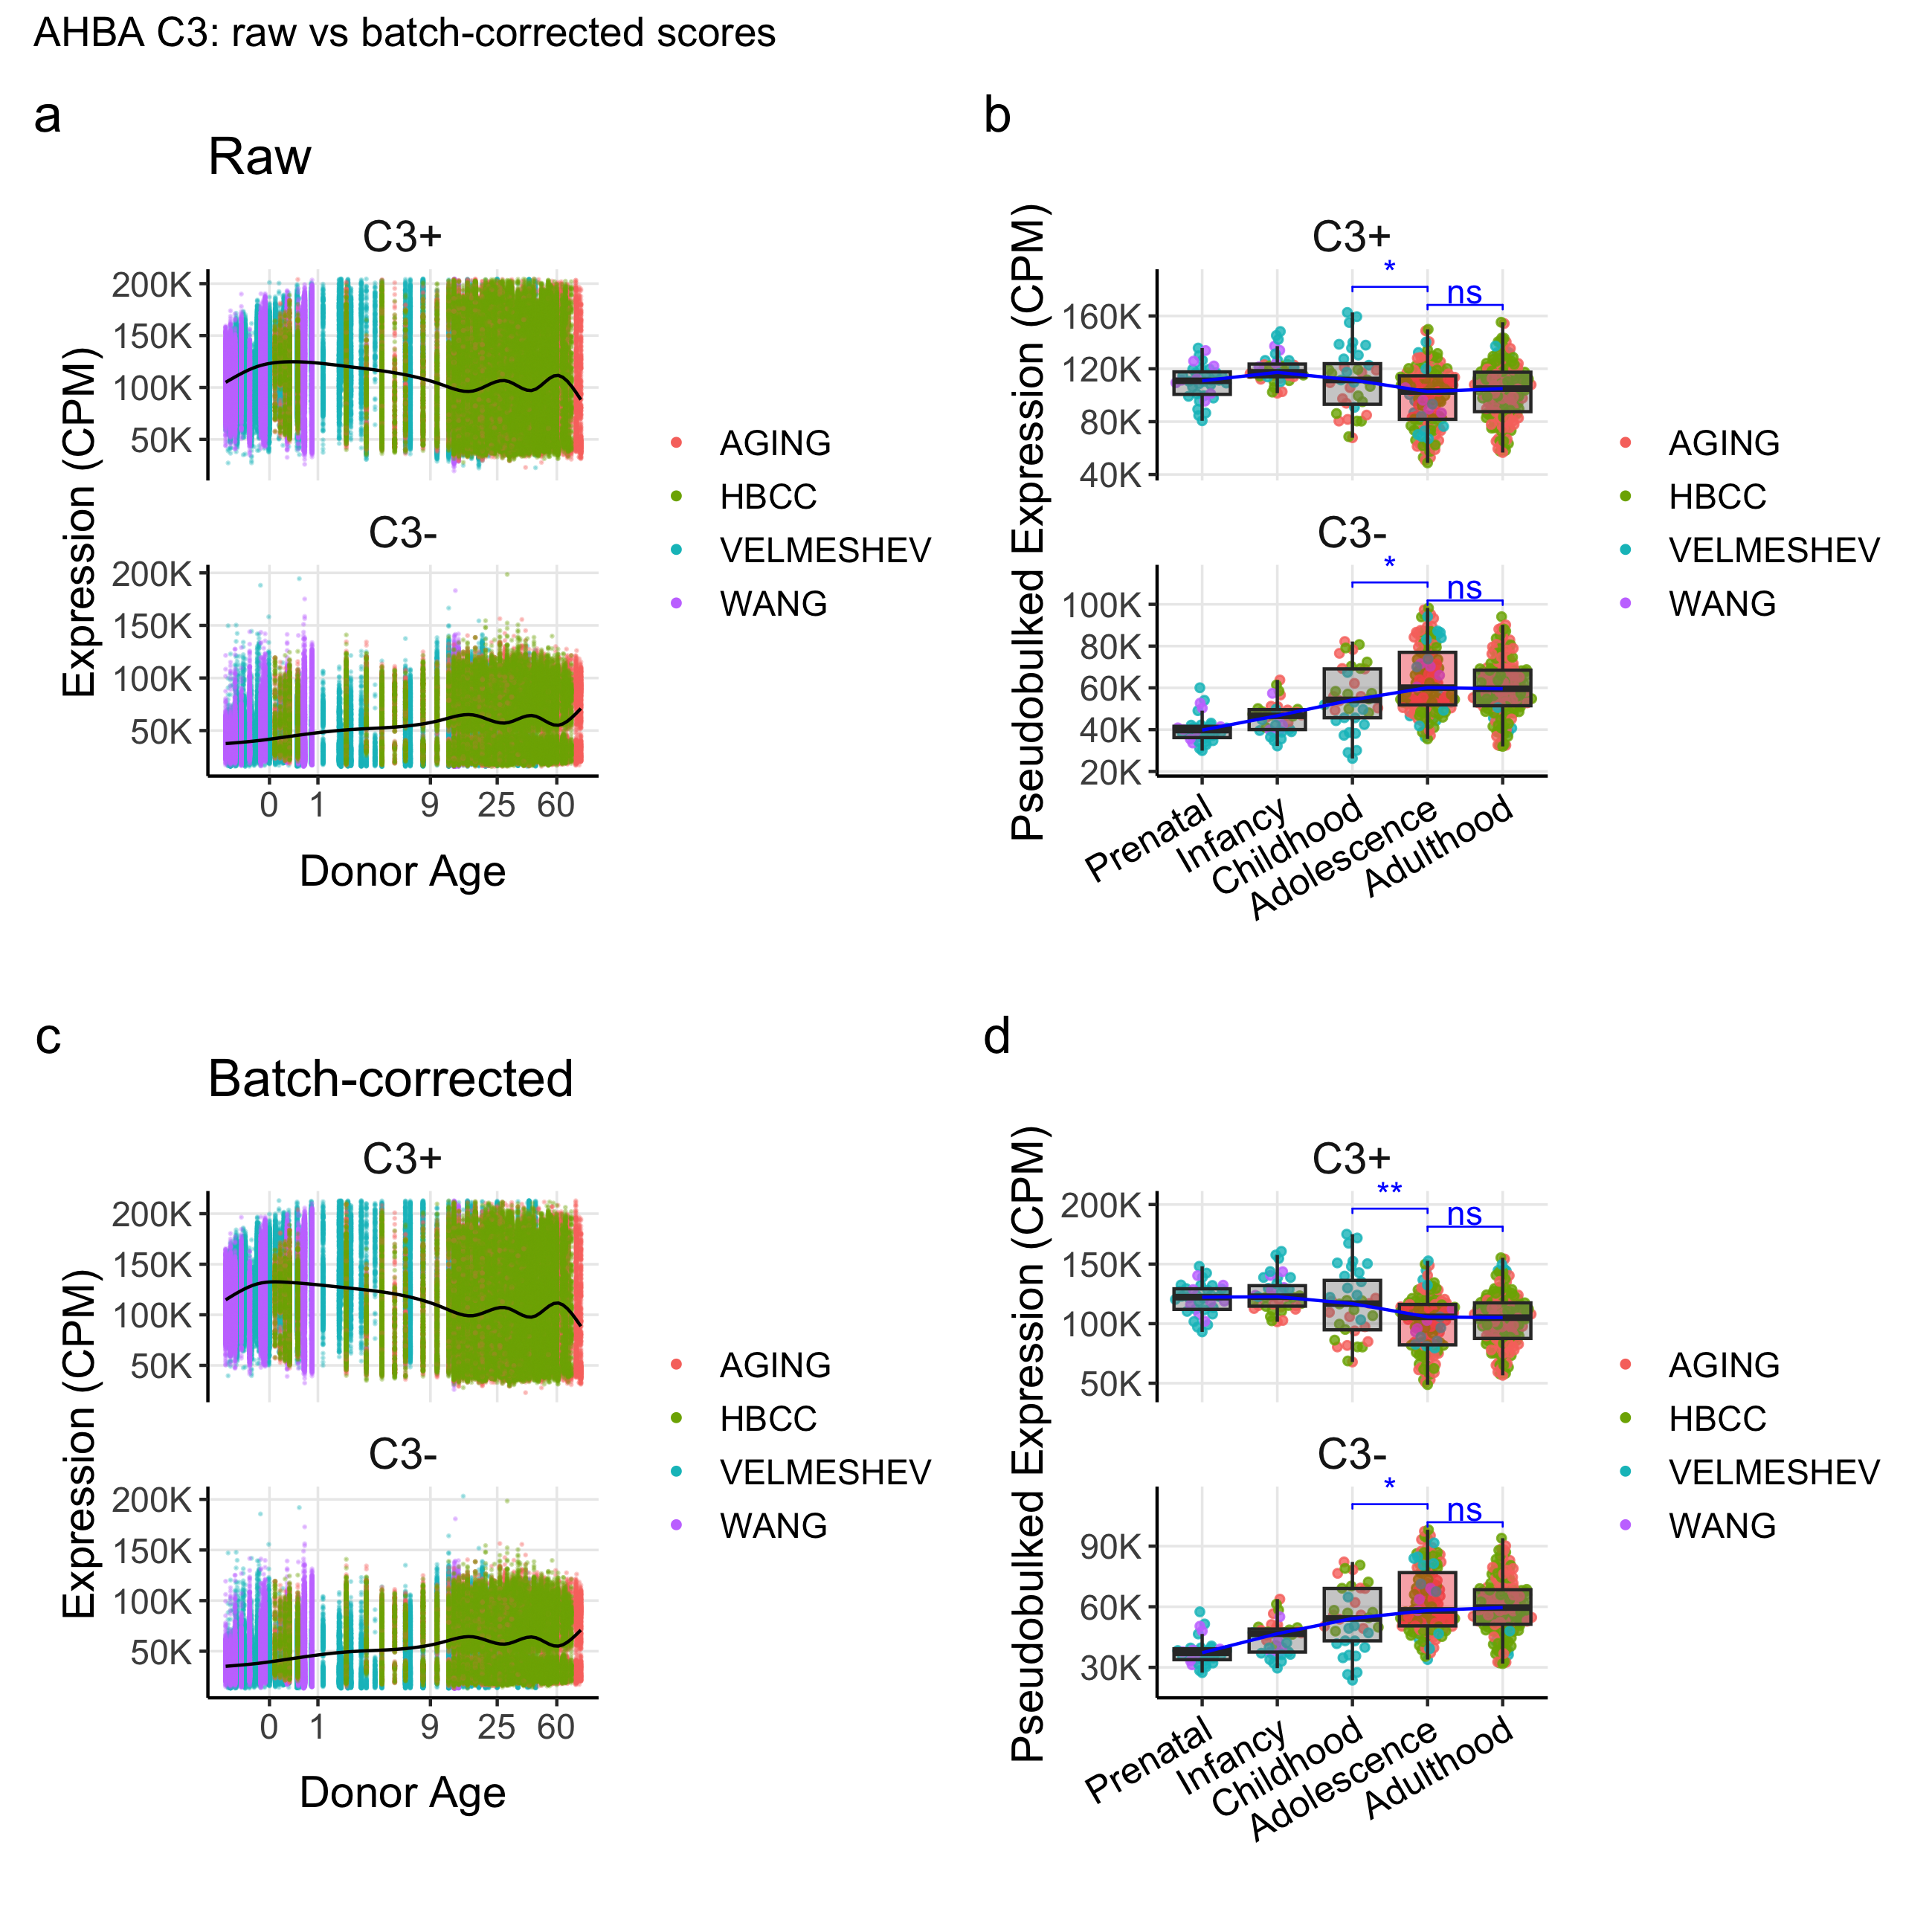

In [11]:
%%R -i final_df -i code_dir -w 220 -h 220 -u mm -r 300

source_path <- file.path(code_dir, "age_plots.r")
message(paste("Sourcing functions from", source_path))
source(source_path)

message("Processing data in R...")

# Clean/Process Data for R
df <- final_df %>%
  rename(Individual = individual) %>%
  mutate(Age_log2 = log2(age_years+1)) %>%
  mutate(age_range = case_when(
    age_years < 0 ~ "Prenatal",
    age_years < 1 ~ "Infancy",
    age_years >= 1 & age_years < 9 ~ "Childhood",
    age_years >= 9 & age_years < 25 ~ "Adolescence",
    age_years >= 25 ~ "Adulthood"
  )) %>%
  mutate(age_range = factor(age_range, ordered=T, levels=c("Prenatal","Infancy", "Childhood", "Adolescence", "Adulthood"))) %>%
  filter(!is.na(age_range)) %>%
  mutate(C = factor(C, levels=c('C3+', 'C3-')))

# --- Raw plots ---
df_raw <- df %>% filter(correction == 'raw')

color_col <- "source"
p_age_raw <- df_raw %>% plot_age(color_var = color_col) + ggtitle("Raw")

comparisons <- list(
    c('Adolescence', 'Adulthood'),
    c('Adolescence', 'Childhood')
)
df_box_raw <- df_raw %>% rename(network = C)
p_boxes_raw <- df_box_raw %>% plot_boxes(color_var='source') + stat_compare_means(comparisons = comparisons, color='blue', label='p.signif')

# --- Corrected plots ---
df_corr <- df %>% filter(correction == 'corrected')

p_age_corr <- df_corr %>% plot_age(color_var = color_col) + ggtitle("Batch-corrected")

df_box_corr <- df_corr %>% rename(network = C)
p_boxes_corr <- df_box_corr %>% plot_boxes(color_var='source') + stat_compare_means(comparisons = comparisons, color='blue', label='p.signif')

# Combine: raw on top, corrected on bottom
p_final <- (p_age_raw | p_boxes_raw) / (p_age_corr | p_boxes_corr) +
    plot_annotation(tag_levels='a', title="AHBA C3: raw vs batch-corrected scores")

p_final